In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Data Sources

This project combines multiple datasets including TikTok trending songs,
Spotify streaming data and Instagram trend data.

These datasets are merged to analyze the impact of social media popularity
on music streaming performance.

In [4]:
tiktok = pd.read_csv("tiktok.csv")
spotify = pd.read_csv("Spotify_Youtube.csv")
instagram = pd.read_csv("Trend Data Dashboard - Instagram_Snapchat.csv")


In [24]:
tiktok["release_date"] = tiktok["release_date"].astype(str)
tiktok["year"] = tiktok["release_date"].str[:4]
tiktok["year"] = pd.to_numeric(tiktok["year"], errors="coerce")
# TikTok became globally influential around 2019.
# For this reason, the analysis focuses on songs released from 2019 onwards.
tiktok = tiktok[tiktok["year"] >= 2019]

In [7]:
spotify = spotify.rename(columns={
    "Track":"track_name",
    "Artist":"artist_name",
    "Stream":"spotify_streams",
    "Views":"youtube_views"
})

In [8]:
tiktok["track_name"] = tiktok["track_name"].str.lower()
spotify["track_name"] = spotify["track_name"].str.lower()

df = pd.merge(tiktok, spotify, on="track_name", how="inner")

print("Merged rows:", len(df))

Merged rows: 3659


In [9]:
instagram = instagram.rename(columns={"Music":"track_name"})
instagram["track_name"] = instagram["track_name"].str.lower()

df = pd.merge(df, instagram, on="track_name", how="left")

Exploratory Data Analysis (EDA)

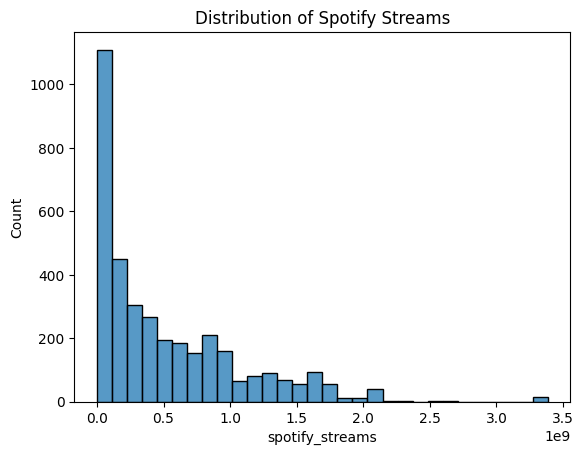

In [30]:
# Spotify Streams Distribution
sns.histplot(df["spotify_streams"], bins=30)
plt.title("Distribution of Spotify Streams")
plt.show()

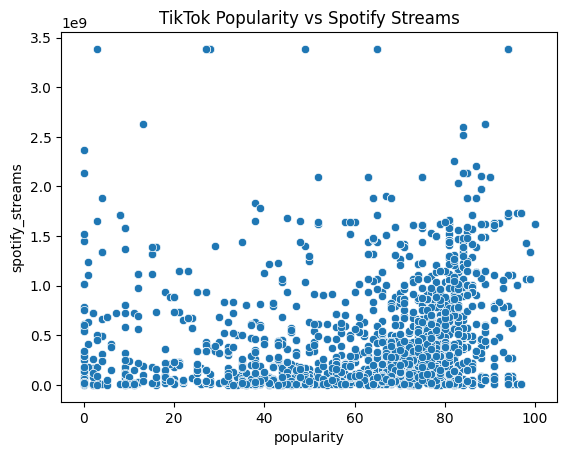

In [29]:
# TikTok Popularity vs Spotify Streams (Scatter Plot)
sns.scatterplot(x=df["popularity"], y=df["spotify_streams"])
plt.title("TikTok Popularity vs Spotify Streams")
plt.show()

In [16]:
df["year"] = tiktok["year"]


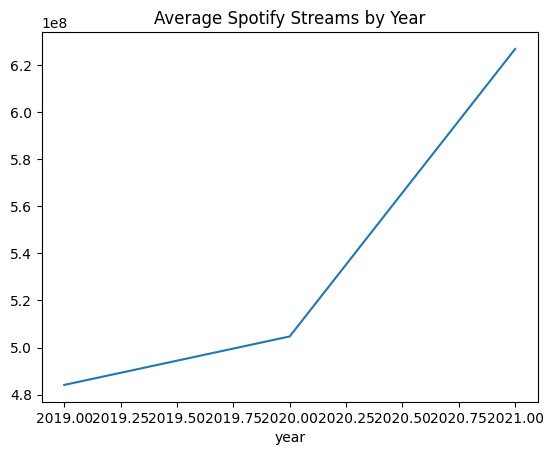

In [28]:
#  Spotify Streams by Year (Line Plot)
yearly = df.groupby("year")["spotify_streams"].mean()

sns.lineplot(x=yearly.index, y=yearly.values)
plt.title("Average Spotify Streams by Year")
plt.show()

In [25]:
from scipy.stats import pearsonr

In [19]:
corr, p = pearsonr(df["popularity"], df["spotify_streams"])

print("Correlation:", corr)
print("P-value:", p)

Correlation: nan
P-value: nan


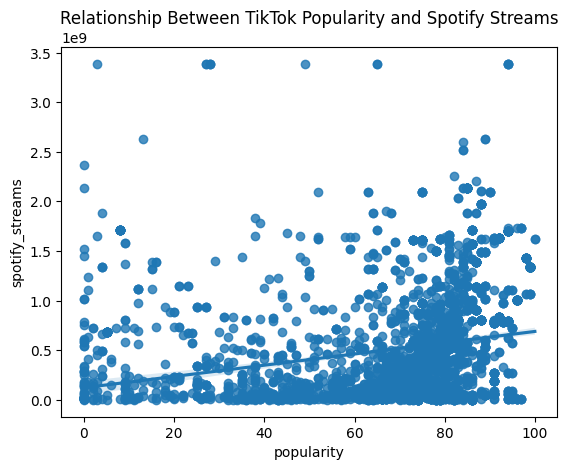

In [20]:
sns.regplot(x=df["popularity"], y=df["spotify_streams"])
plt.title("Relationship Between TikTok Popularity and Spotify Streams")
plt.show()

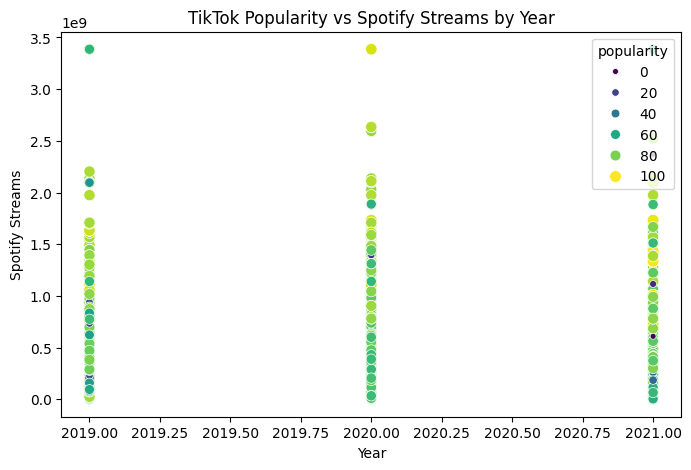

In [26]:
# TikTok Popularity vs Spotify Streams by Year
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["year"],
    y=df["spotify_streams"],
    size=df["popularity"],
    hue=df["popularity"],
    palette="viridis"
)

plt.title("TikTok Popularity vs Spotify Streams by Year")

plt.xlabel("Year")
plt.ylabel("Spotify Streams")

plt.show()

Hypothesis Testing

Null Hypothesis (H0)
There is no relationship between TikTok popularity and Spotify streams.

Alternative Hypothesis (H1)
There is a significant relationship between TikTok popularity and Spotify streams.

In [23]:
from scipy.stats import pearsonr

temp = df[["popularity","spotify_streams"]].dropna()

corr, p = pearsonr(temp["popularity"], temp["spotify_streams"])

print("Correlation:", corr)
print("P-value:", p)

Correlation: 0.22327436574564086
P-value: 3.6554136505533673e-42


Hypothesis Test Result

Pearson correlation analysis was conducted to examine the relationship between TikTok popularity and Spotify streaming counts.
	•	Correlation coefficient (r): 0.223
	•	P-value: 3.66 × 10⁻⁴²

The correlation coefficient indicates a positive relationship, meaning that songs with higher TikTok popularity tend to have higher Spotify streaming counts.

Since the p-value is much smaller than 0.05, the null hypothesis is rejected. This suggests that there is a statistically significant relationship between TikTok popularity and Spotify streams.


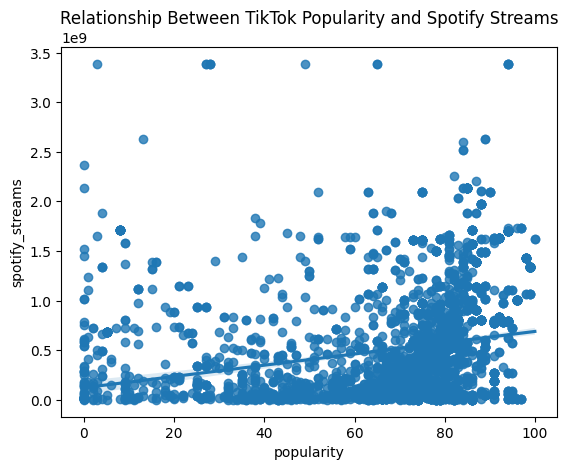

In [27]:
sns.regplot(x=df["popularity"], y=df["spotify_streams"])

plt.title("Relationship Between TikTok Popularity and Spotify Streams")

plt.show()

Conclusion

The analysis suggests that TikTok popularity is associated with increased Spotify streams. Songs that gain traction on TikTok often receive higher streaming counts on Spotify. This supports the idea that short-form social media platforms play a major role in shaping music consumption trends.